**Principal Component Analysis**
|Mouse|Gene1|Gene2|Gene3|Gene4|
|---|---|---|---|---|
|1|10|6|1.2|5|
|2|11|4|9|7|
|3|8|5|10|6|
|4|3|3|2.5|2|
|5|1|2.8|1.3|4|
|6|2|1|2|7|

If we only measure Gene 1 how do I separate the mice?

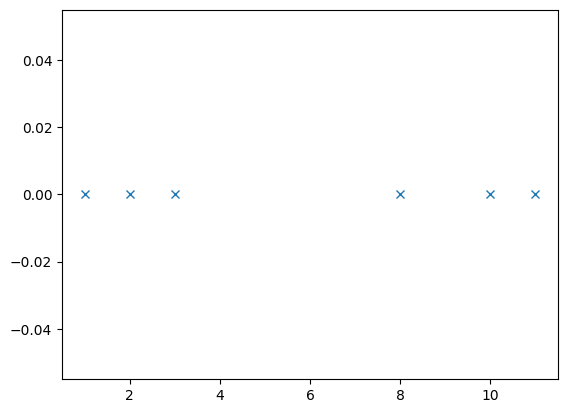

In [1]:
import numpy as np 
from matplotlib import pyplot as plt 
gene1 = [10, 11, 8, 3, 1, 2]
plt.plot(gene1, np.zeros_like(gene1), 'x')

Mice 1, 2, and 3 are more similar to each other than they are to mice 4, 5, and 6 along gene1. Now consider 2 genes.

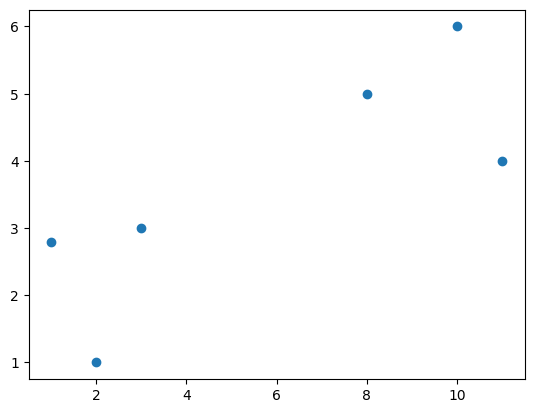

In [2]:
gene2 = [6, 4, 5, 3, 2.8, 1]
plt.scatter(gene1, gene2)

- PCA can tell us which gene or variable or combination of variables is the mist valuable for clustering
- To understand PCA we will use a dataset with the first

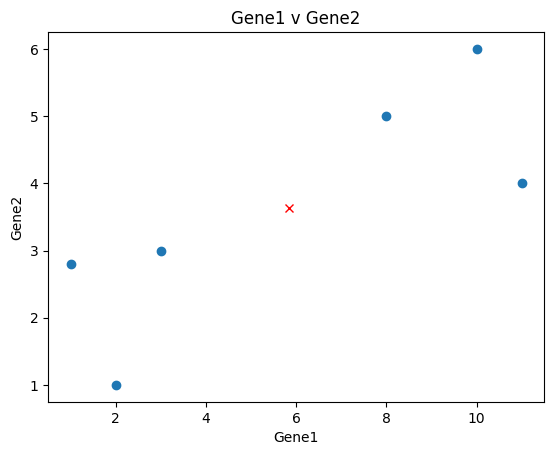

In [3]:
plt.scatter(gene1, gene2)
plt.title("Gene1 v Gene2")
plt.xlabel("Gene1")
plt.ylabel("Gene2")
gene1average = np.average(gene1)
gene2average = np.average(gene2)
plt.plot(gene1average, gene2average, 'rx')

- We will shift the data so that the centre is at the origin
- Subtract average from each point

In [4]:
gene1 = gene1 - gene1average
gene2 = gene2 - gene2average
print(gene1)
print(gene2)

[ 4.16666667  5.16666667  2.16666667 -2.83333333 -4.83333333 -3.83333333]
[ 2.36666667  0.36666667  1.36666667 -0.63333333 -0.83333333 -2.63333333]


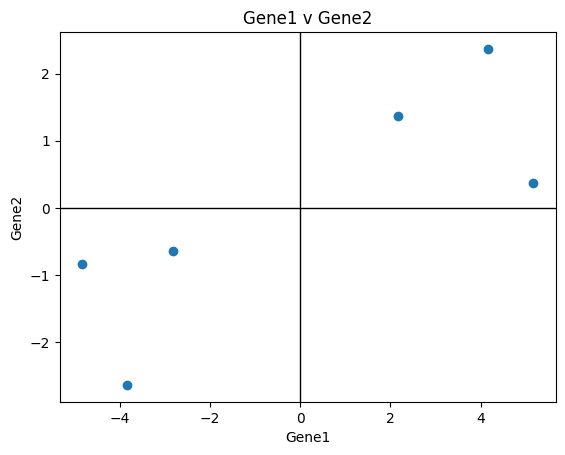

In [5]:
plt.scatter(gene1, gene2)
plt.title("Gene1 v Gene2")
plt.xlabel("Gene1")
plt.ylabel("Gene2")
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

- Shifting the data did not change how the points are positioned relative to each other
- Now that the data is centred at the origin we can fit a line to it
- Start with a random line through the origin and rotate until it is as good as possible
- We need to consider how PCA decides if a fit is good or not
- Consider a random line through the origin
- To quantify how good the line is, PCA will project each data point onto the line and then measure the distances from the point to the line and try and find the line that minimises the distances
- It can try and find a line that maximises the distances of the projected points to the origin
- $c^2 = a^2 + b^2$, since $c$ is fixed, as $a$ gets smaller $b$ ges bigger and nice versa 
- PCA can either minimise $a$ or maximise $b$
- Intuitively it is more obvious to minimise $a$ BUT, it is easier to caluclate $b$ the distance from the projected point to the origin, so PCA find the line of best fit by maximising the squared distances of the projected point to the origin
- Rotate the line to find the larget sum of squares (SS)
- This line is Principal Component 1 or PC1 for short

In [6]:
from scipy import stats
slope, intercept, _, _, _ = stats.linregress(gene1, gene2)
print(slope)
print(intercept)

0.32302284710017576
-1.6964884226316686e-16


- PCA1 has slope 0.323. In other words for every three units we go along the gene1 axis, we go up one in the gene2 axis
- This means that the data is mostly spread out along gene1 and a little spread out along gene2
- To make PC1, we take 3 parts gene1 and 1 part gene2
- The ratio of gene1 to gene2 tells you that gene1 is more important when it comes to describing how the data is spread out
- PC1 is a **linear combination** of gene1 and gene2
- When you do PCA using Singular Value Decomposition (SVD), the recipe for PC1 is scaled so that its length is 1. In our case we need to divide by $\sqrt(10)$
- PC1 = $\frac{3}{\sqrt{10}}gene1 + \frac{1}{\sqrt{10}}gene$
- The unit vector is called the singular vector or the eigenvector for PC1
- The proportions of each gene are called "Loading Scores"
- PCA calls the average of the SS distances for the best fit line the eigenvalue for PC1
- $\frac{SS(distances for PC1)}{n-1}$ = Eigenvalue for PC1
- $\sqrt{SS(distances for PC1)}$ = singular value for PC1
- Because our example is 2D, PC2 is the line goes through the origin, perpendicular to PC1
- PC2 = -1gene1 + 3 gene2
- Scaling PC2 to get a unit vector $\frac{-1}{\sqrt{10}}gene1 + \frac{3}{\sqrt{10}}gene2$ 
- For PC2 gene2 is three times more important that gene1
- To draw the final plot, rotate everything so that PC1 is horizontal. Then we can use the projected points to see where the samples are in the PCA plot
- Eigenvalues are measures of variation
- For the sake of this example suppose the variation for PC1 is 15 and the variation for PC2 is 3
- Total variation = 18
- This means that PC1 accounts for 15/18=83% of the total variation around PCs
- A scree plot is a graphical representation of percentages of variation that each PC accounts for
- Kaiser criterion says that we should retain PCs whose eigenvalue > 1


**PCA with 3 variables**
- Centre the daya
- Find the line of best fit through the origin
- PC1 = 0.62 gene1 + 0.15 gene2 + 0.77 gene3
- PC2 is the nest best fitting line that goes through the origin that is at right angles to PC1
- PC3 is the next best fitting line through the origin that is orthogonal to PC1 and PC2
- In theory there is one PC per gene (or variable) but in practice the number of PCs is either the number of variables or the number of of samples, whichever is smaller
- Once we have all of the PCs we can use the eigenvalues to determine the proportion of the variation that the PC accounts for

In [7]:
import pandas as pd
import numpy as np
import random as rd 
from sklearn.decomposition import PCA
from sklearn import preprocessing
import matplotlib.pyplot as plt 


In [8]:
genes = ['gene'+str(i) for i in range (1, 101)]
wt = ['wt'+str(i) for i in range(1, 6)]
ko = ['ko'+str(i) for i in range(1, 6)]

In [9]:
data = pd.DataFrame(columns=(*wt, *ko), index = genes)
data

,wt1,wt2,wt3,wt4,wt5,ko1,ko2,ko3,ko4,ko5
gene1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gene2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gene3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gene4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gene5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
gene96,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gene97,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gene98,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gene99,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
for gene in data.index:
    data.loc[gene, 'wt1':'wt5'] = np.random.poisson(lam=rd.randrange(10, 100), size = 5)
    data.loc[gene, 'ko1':'ko5'] = np.random.poisson(lam=rd.randrange(10, 100), size = 5)

In [11]:
print(data.head())

      wt1 wt2 wt3 wt4 wt5 ko1 ko2 ko3 ko4 ko5
gene1  30  30  32  37  42  63  73  73  77  78
gene2  76  73  58  66  68  50  49  57  61  51
gene3  12  19   6  17  16  67  60  70  58  61
gene4  22  25  21  28  19  39  55  59  46  53
gene5  37  37  42  50  51  14  20  14  16   7


In [12]:
print(data.shape)

(100, 10)


In [13]:
scaled_data = preprocessing.scale(data.T)

In [14]:
scaled_data

array([[-1.17876332,  1.65455236, -1.06311586, -0.99604378,  0.52869128,
         0.83485333, -1.06871139,  1.10999621,  0.93391738, -0.83862787,
        -0.98387792,  1.34015667, -0.9197138 , -0.82914653,  0.47231586,
        -0.7947443 ,  1.21586101, -0.01502613,  0.98756234, -0.89592019,
        -1.11252904,  1.02820246,  1.26233283, -0.83189885, -1.07592425,
        -0.29811502, -0.89931678,  1.2122111 ,  0.15068493,  0.93927908,
        -1.17165884, -1.21321787, -0.88741853, -0.76753648, -0.87234043,
        -1.7274504 ,  0.44303622,  1.04196384, -1.42980937,  0.7402658 ,
        -1.05829781,  0.95198571, -1.22408324,  1.04811195, -0.9219789 ,
         1.58289858, -1.56339331, -1.52706931,  1.14902148, -1.09702004,
        -0.74322643,  1.01244747, -1.57416831, -1.05726299,  1.53751896,
         0.79386372, -1.38717971, -0.9407529 ,  1.12724296,  2.53949215,
         1.49889578,  1.48475527, -1.14588713,  0.52476414,  0.16935374,
        -0.97456694, -0.80479273, -0.67504384, -0.9

In [15]:
pca = PCA()
pca.fit(scaled_data)
pca_data = pca.transform(scaled_data)
per_var = np.round(pca.explained_variance_ratio_ * 100, decimals=1)
per_var

array([75.3,  5.4,  4.7,  3.7,  3.1,  2.7,  2.2,  1.8,  1.1,  0. ])

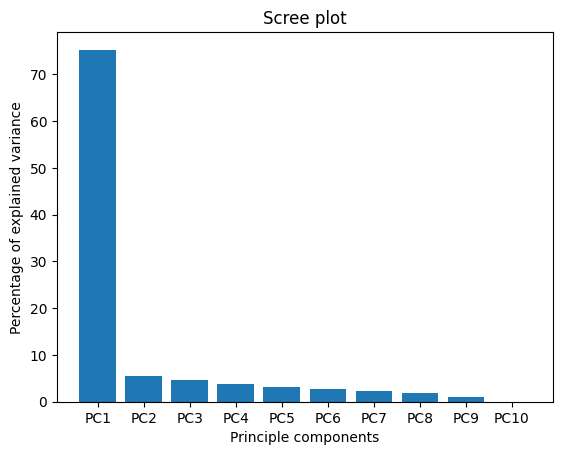

In [16]:
labels = ['PC'+str(i) for i in range(1, len(per_var)+1)]
plt.bar(x=range(1, len(per_var)+1 ), height=per_var, tick_label=labels)
plt.ylabel("Percentage of explained variance")
plt.xlabel("Principle components")
plt.title("Scree plot")
plt.show()

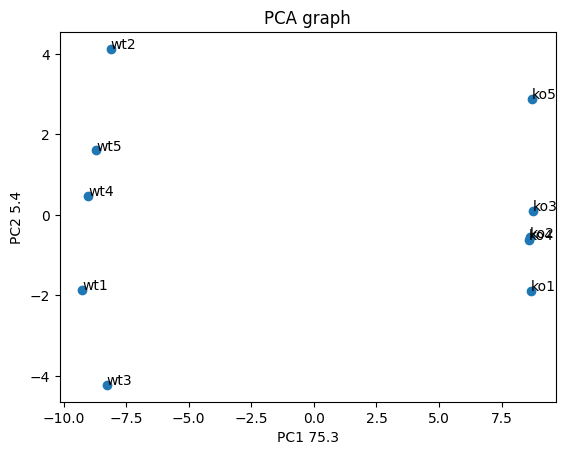

In [17]:
pca_df = pd.DataFrame(pca_data, index=[*wt, *ko], columns = labels)
plt.scatter(pca_df.PC1, pca_df.PC2)
plt.title("PCA graph")
plt.xlabel(f'PC1 {per_var[0]}')
plt.ylabel(f'PC2 {per_var[1]}')
for sample in pca_df.index:
    plt.annotate(sample, (pca_df.PC1.loc[sample], pca_df.PC2.loc[sample]))
plt.show()

In [18]:
loading_scores = pd.Series(pca.components_[0], index = genes)
print(*loading_scores)

0.11135483505392674 -0.09290965736041443 0.11326776743470998 0.10694654422081454 -0.10871185600557315 -0.11205953899343356 0.11357325129105722 -0.09702945678750693 -0.1138607429804294 0.11100802335867202 0.11376468090264226 -0.10624954816131037 0.11170666004897688 0.11414591356714307 -0.11129342074858813 0.11105916577646717 -0.08865324738863811 0.09491160855396663 -0.10816326556912081 0.1128680231523061 0.07101573735289782 -0.10838593818998654 -0.11253689570171425 0.054173425091733264 0.11411375751347803 0.10024603704273724 0.10342787126418203 -0.04726827417868566 -0.09337316351460508 -0.11064788244708797 0.059665411830461625 0.10974352537860893 0.08941406797163963 0.11254890835894268 -0.011545141270856445 0.09984715718912633 -0.09812253485732172 -0.10893888932180455 0.006577255081302725 -0.10067341068879757 0.11418417744567079 -0.11470901915636088 0.10400225597857 -0.1127660664859601 0.1122404218995593 -0.10867941395159715 -0.0535483056007638 0.09896104342097146 -0.1131517918089471 0.

In [19]:
sorted_loading_scores = loading_scores.abs().sort_values(ascending=False)
top_10_genes = sorted_loading_scores[0:10].index.values
top_10_genes

<StringArray>
['gene54', 'gene42', 'gene97', 'gene96', 'gene41', 'gene14', 'gene25',
 'gene82',  'gene9', 'gene11']
Length: 10, dtype: str

**PCA on MNIST**
- MNIST data has redundant pixels. Getting rid of the pixels will:
- Faster training and inference
- Data visualisation easier
- PCA is the process of figuring out which pixel is the most important
- Scale features before applying PCA
- Accuracy might drop

In [20]:
import pandas as pd
from sklearn.datasets import load_digits


In [21]:
dataset = load_digits()
dataset.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [22]:
dataset

{'data': array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  2., ..., 12.,  0.,  0.],
        [ 0.,  0., 10., ..., 12.,  1.,  0.]], shape=(1797, 64)),
 'target': array([0, 1, 2, ..., 8, 9, 8], shape=(1797,)),
 'frame': None,
 'feature_names': ['pixel_0_0',
  'pixel_0_1',
  'pixel_0_2',
  'pixel_0_3',
  'pixel_0_4',
  'pixel_0_5',
  'pixel_0_6',
  'pixel_0_7',
  'pixel_1_0',
  'pixel_1_1',
  'pixel_1_2',
  'pixel_1_3',
  'pixel_1_4',
  'pixel_1_5',
  'pixel_1_6',
  'pixel_1_7',
  'pixel_2_0',
  'pixel_2_1',
  'pixel_2_2',
  'pixel_2_3',
  'pixel_2_4',
  'pixel_2_5',
  'pixel_2_6',
  'pixel_2_7',
  'pixel_3_0',
  'pixel_3_1',
  'pixel_3_2',
  'pixel_3_3',
  'pixel_3_4',
  'pixel_3_5',
  'pixel_3_6',
  'pixel_3_7',
  'pixel_4_0',
  'pixel_4_1',
  'pixel_4_2',
  'pixel_4_3',
  'pixel_4_4',
  'pixel_4_5',
  'pixel_4_6',
  'pixel_4_7'

In [23]:
dataset.data.shape


(1797, 64)

In [24]:
dataset.data[0]

array([ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 15., 10.,
       15.,  5.,  0.,  0.,  3., 15.,  2.,  0., 11.,  8.,  0.,  0.,  4.,
       12.,  0.,  0.,  8.,  8.,  0.,  0.,  5.,  8.,  0.,  0.,  9.,  8.,
        0.,  0.,  4., 11.,  0.,  1., 12.,  7.,  0.,  0.,  2., 14.,  5.,
       10., 12.,  0.,  0.,  0.,  0.,  6., 13., 10.,  0.,  0.,  0.])

In [25]:
dataset.data[0].reshape(8, 8)

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

<Figure size 640x480 with 0 Axes>

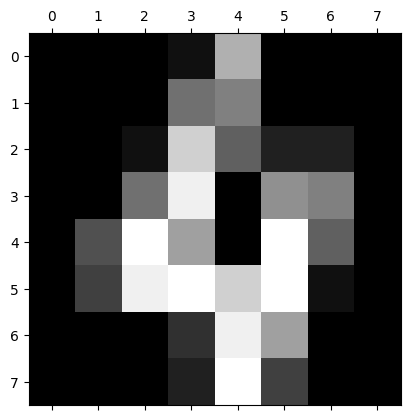

In [26]:
from matplotlib import pyplot as plt
plt.gray()
plt.matshow(dataset.data[4].reshape(8, 8))

In [27]:
dataset.target[4]

np.int64(4)

In [28]:
import numpy as np
np.unique(dataset.target)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [29]:
df = pd.DataFrame(dataset.data, columns=dataset.feature_names)

In [30]:
df.head()

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0


In [31]:
df.describe()

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
count,1797.0,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,...,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000
mean,0.0,0.303840,5.204786,11.835838,11.848080,5.781859,1.362270,0.129661,0.005565,1.993879,...,3.725097,0.206455,0.000556,0.279354,5.557596,12.089037,11.809126,6.764051,2.067891,0.364496
std,0.0,0.907192,4.754826,4.248842,4.287388,5.666418,3.325775,1.037383,0.094222,3.196160,...,4.919406,0.984401,0.023590,0.934302,5.103019,4.374694,4.933947,5.900623,4.090548,1.860122
min,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.0,0.000000,1.000000,10.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,11.000000,10.000000,0.000000,0.000000,0.000000
50%,0.0,0.000000,4.000000,13.000000,13.000000,4.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,4.000000,13.000000,14.000000,6.000000,0.000000,0.000000
75%,0.0,0.000000,9.000000,15.000000,15.000000,11.000000,0.000000,0.000000,0.000000,3.000000,...,7.000000,0.000000,0.000000,0.000000,10.000000,16.000000,16.000000,12.000000,2.000000,0.000000
max,0.0,8.000000,16.000000,16.000000,16.000000,16.000000,16.000000,15.000000,2.000000,16.000000,...,16.000000,13.000000,1.000000,9.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000


In [32]:
X = df
y = dataset.target

In [33]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[ 0.        , -0.33501649, -0.04308102, ..., -1.14664746,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649, -1.09493684, ...,  0.54856067,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649, -1.09493684, ...,  1.56568555,
         1.6951369 , -0.19600752],
       ...,
       [ 0.        , -0.33501649, -0.88456568, ..., -0.12952258,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649, -0.67419451, ...,  0.8876023 ,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649,  1.00877481, ...,  0.8876023 ,
        -0.26113572, -0.19600752]], shape=(1797, 64))

In [34]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=30)


In [35]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.9722222222222222

In [36]:
from sklearn.decomposition import PCA
pca = PCA(0.95)
X_pca = pca.fit_transform(X_scaled)
X_pca.shape

(1797, 40)

In [37]:
X_pca

array([[-1.91421366, -0.95450157, -3.94603482, ...,  0.81405925,
         0.0249306 , -0.32193146],
       [-0.58898033,  0.9246358 ,  3.92475494, ...,  0.20026094,
         0.08710843,  0.48914299],
       [-1.30203906, -0.31718883,  3.02333293, ..., -0.214596  ,
        -1.2788745 , -0.54583387],
       ...,
       [-1.02259599, -0.14791087,  2.46997365, ...,  0.60136463,
         0.41238798, -1.20886377],
       [-1.07605522, -0.38090625, -2.45548693, ...,  0.43756556,
        -0.69863483,  0.44339963],
       [ 1.25770233, -2.22759088,  0.28362789, ..., -0.38108638,
         0.12855104, -1.32137195]], shape=(1797, 40))

In [38]:
per_var = pca.explained_variance_ratio_

In [39]:
per_var

array([0.12033916, 0.09561054, 0.08444415, 0.06498408, 0.04860155,
       0.0421412 , 0.03942083, 0.03389381, 0.02998221, 0.02932003,
       0.02781805, 0.02577055, 0.02275303, 0.0222718 , 0.02165229,
       0.01914167, 0.01775547, 0.01638069, 0.0159646 , 0.01489191,
       0.0134797 , 0.01271931, 0.01165837, 0.01057647, 0.00975316,
       0.00944559, 0.00863014, 0.00836643, 0.00797693, 0.00746471,
       0.00725582, 0.00691911, 0.00653909, 0.00640793, 0.00591384,
       0.00571162, 0.00523637, 0.00481808, 0.00453719, 0.00423163])

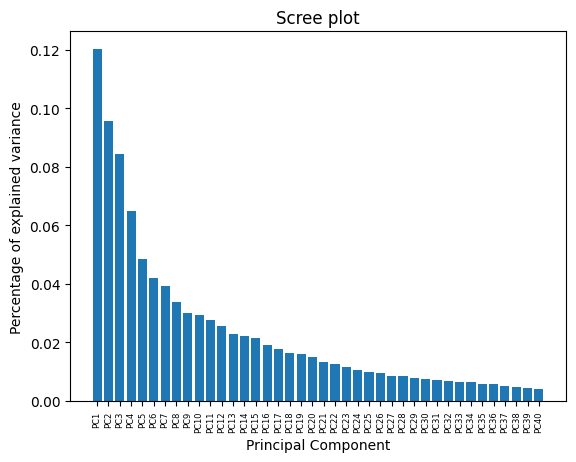

In [40]:
labels = ['PC' + str(i) for i in range(1, len(per_var)+1)]
plt.bar(x = range(1, len(per_var)+1), height = per_var, tick_label=labels)
plt.xticks(rotation='vertical', fontsize=6)
plt.ylabel("Percentage of explained variance")
plt.xlabel("Principal Component")
plt.title("Scree plot")
plt.show()

In [41]:
pca.n_components_

np.int64(40)

In [42]:
from sklearn.model_selection import train_test_split
X_train_pca, X_test_pca, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=30)

In [43]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train_pca, y_train)
model.score(X_test_pca, y_test)

0.9638888888888889